Cell count: 5038


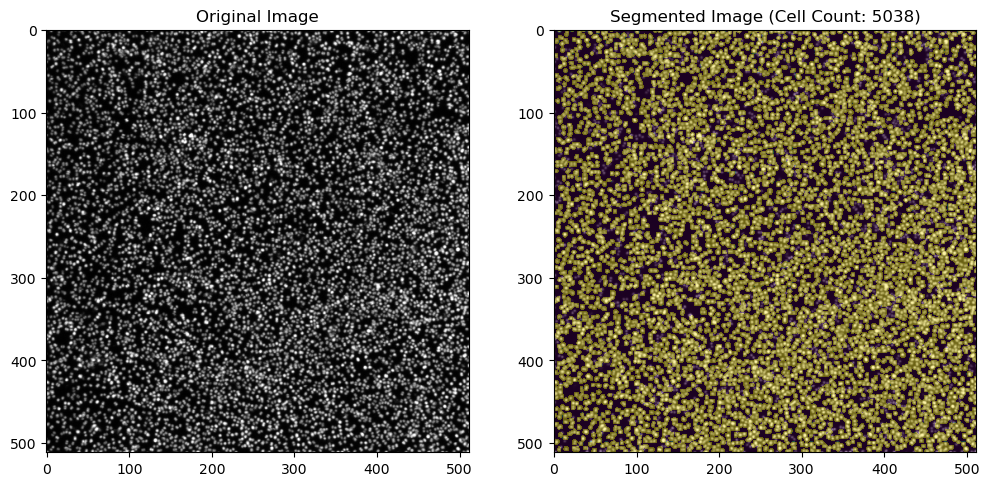

CPU times: user 8.93 s, sys: 492 ms, total: 9.42 s
Wall time: 9.08 s


In [47]:
%%time
from cellpose import models, io, plot
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2gray

# Load the image
image_path = 'seq6020_8bit.png'  # Update this with the correct path to your image
img = io.imread(image_path)

# Convert the image to grayscale
# gray_img = rgb2gray(img)

gray_img = img

# Initialize the Cellpose model
model = models.Cellpose(gpu=True, model_type='cyto')

flow_threshold = 0.99 # A higher threshold will only consider strong flows as cell boundaries
cellprob_threshold = 0.01  # A higher threshold will result in only confident predictions being considered as cell regions

# Run Cellpose
masks, flows, styles, diams = model.eval([gray_img], diameter=5, channels=[0, 0], flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold)

# Count cells
cell_count = np.max(masks[0])
print(f'Cell count: {cell_count}')

# Plot the results
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title('Original Image')
axes[1].imshow(gray_img, cmap='gray')
axes[1].imshow(masks[0], cmap=None, vmin=0, vmax=1, alpha=0.4)
axes[1].set_title(f'Segmented Image (Cell Count: {cell_count})')
plt.show()


Bacteria count: 6022


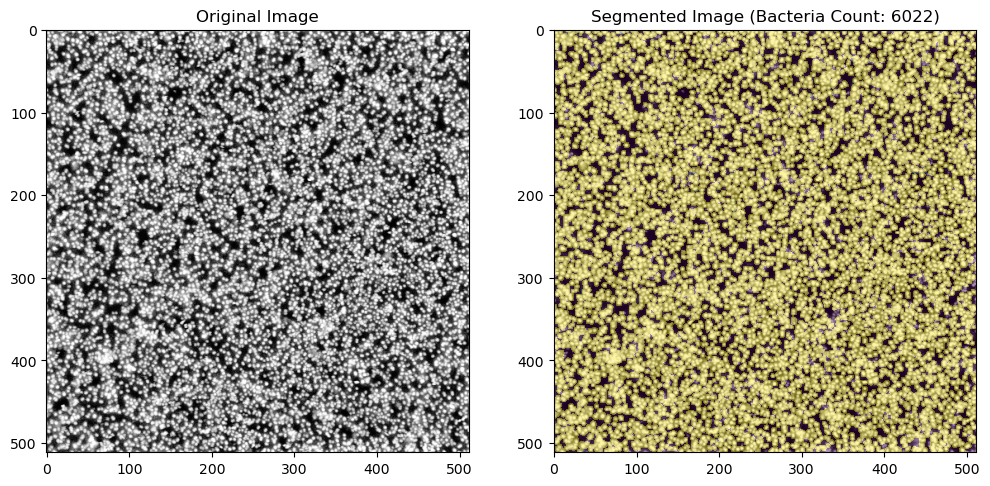

CPU times: user 9.2 s, sys: 470 ms, total: 9.67 s
Wall time: 9.34 s


In [84]:
%%time
from cellpose import models, io, plot
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2gray
from skimage import exposure, filters

# Load the image
image_path = 'MAX_nd11560-1.png'  # Update this with the correct path to your image
img = io.imread(image_path)

# Enhance contrast
enhanced_img = exposure.equalize_adapthist(img, clip_limit=0.6)

# Optional: Smooth the image to reduce noise
smoothed_img = filters.gaussian(enhanced_img, sigma=0.1)

# Use the enhanced and smoothed image for Cellpose
gray_img = rgb2gray(smoothed_img)

# gray_img = smoothed_img

# Initialize the Cellpose model
model = models.Cellpose(gpu=True, model_type='cyto')

flow_threshold = 0.99  # Lowering the threshold to consider more boundaries
cellprob_threshold = 0.01  # Increasing threshold for more confident cell regions

# Run Cellpose
masks, flows, styles, diams = model.eval([gray_img], diameter=5.0, channels=[0, 0], flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold)

# Count cells
cell_count = np.max(masks[0])
print(f'Bacteria count: {cell_count}')

# Plot the results
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title('Original Image')
axes[1].imshow(gray_img, cmap='gray')
axes[1].imshow(masks[0], cmap=None, vmin=0, vmax=1, alpha=0.4)
axes[1].set_title(f'Segmented Image (Bacteria Count: {cell_count})')
plt.show()
